In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import time
import types
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.decomposition import PCA as SklearnPCA
from statsmodels.tsa.api import VAR

warnings.filterwarnings('ignore')

from meteor import Cmip6MeteorDataGetter, geo_data_utils
from meteor.noise_model.ae_varx import AEVARXNoiseModel
from meteor.noise_model.noise_model_data_utils import build_exog_matrix, create_harmonic_features

from fys9429.ae_experiment_runner import (
    make_configurable_ae,
    ExperimentRegistry,
    run_ae_experiment,
    run_sweep,
    compute_reconstruction_metrics,
    compute_latent_diagnostics,
    compute_varx_diagnostics,
    compute_stochastic_rollout_stability,
)

print("✅ Imports complete")

✅ Imports complete


## Configuration

In [37]:
NOTEBOOK_VAR  = "tas"       # change to 'pr' to repeat for precipitation
MODEL         = 'NorESM2-MM'
VARIABLES     = [NOTEBOOK_VAR]
SCENARIO      = 'ssp245'
LAG_ORDER     = 2
USE_EXOG      = "temp_only"
SEED          = 42
np.random.seed(SEED)

notebook_dir = Path.cwd()
SCRATCH_DIR   = Path("/scratch/johannlf/ae_sweep")
RESULTS_DIR  = notebook_dir / "results"
FIGURE_DIR   = notebook_dir / "figures" / "ae_varx" / NOTEBOOK_VAR
SCRATCH_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Variable  : {NOTEBOOK_VAR}")
print(f"Results   : {RESULTS_DIR}")
print(f"Figures   : {FIGURE_DIR}")

Variable  : tas
Results   : /uio/kant/geo-geofag-u1/johannlf/FYS9429/investigations/monthly_output/results
Figures   : /uio/kant/geo-geofag-u1/johannlf/FYS9429/investigations/monthly_output/figures/ae_varx/tas


## Load CMIP6 data

In [12]:
data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "historical", "ssp245", "ssp126", "ssp585"],
    flds=VARIABLES,
    dbe=['CMIP', 'CMIP', 'ScenarioMIP', 'ScenarioMIP', 'ScenarioMIP'],
    enable_cache=True,
)
cmip6_data_raw = data_getter.make_meteor_training_data_composite(
    ["historical", SCENARIO], MODEL, monthly=True
)
picontrol_data = data_getter.make_meteor_training_data("piControl", MODEL, monthly=True)

picontrol_global  = geo_data_utils.global_mean(picontrol_data[NOTEBOOK_VAR])
picontrol_baseline = picontrol_global.mean()

print(f"CMIP6 {NOTEBOOK_VAR} shape : {cmip6_data_raw[NOTEBOOK_VAR].shape}")
print(f"piControl baseline  : {float(picontrol_baseline):.3f} K")

CMIP6 tas shape : (1, 3012, 192, 288)
piControl baseline  : 286.925 K


## Prepare AE training data

In [13]:
X_ae_mlp = AEVARXNoiseModel.prepare_training_data_for_AE(
    monthly_data=cmip6_data_raw,
    variable_name=NOTEBOOK_VAR,
    picontrol_baseline=picontrol_baseline,
    data_type="mlp",
)
X_ae_conv = AEVARXNoiseModel.prepare_training_data_for_AE(
    monthly_data=cmip6_data_raw,
    variable_name=NOTEBOOK_VAR,
    picontrol_baseline=picontrol_baseline,
    data_type="conv",
)

lats = cmip6_data_raw[NOTEBOOK_VAR].lat.values
lons = cmip6_data_raw[NOTEBOOK_VAR].lon.values

# Smoothed global temperature anomaly  (used as VARX exogenous forcing)
da_tas = cmip6_data_raw[NOTEBOOK_VAR]
if 'ens' in da_tas.dims:
    da_tas = da_tas.mean(dim='ens')
t_globm = (geo_data_utils.global_mean(da_tas) - float(picontrol_baseline)).values
t_glob  = pd.Series(t_globm).rolling(60, center=True, min_periods=1).mean().values

print(f"X_ae_mlp  : {X_ae_mlp.shape}  (T, n_lat*n_lon)")
print(f"X_ae_conv : {X_ae_conv.shape}")
print(f"t_glob    : {t_glob.shape}  [{t_glob.min():.2f}, {t_glob.max():.2f}] K")

X_ae_mlp  : (3012, 55296)  (T, n_lat*n_lon)
X_ae_conv : (3012, 1, 192, 288)
t_glob    : (3012,)  [-0.24, 2.51] K


---
## Phase 1 — PCA Baseline

Run sklearn PCA for `n_modes ∈ {16, 32, 64, 128}`, fit a VARX model on the resulting latent codes, and compute the same set of metrics that `run_ae_experiment` produces.

In [14]:
def run_pca_experiment(
    n_modes: int,
    X_ae_mlp: np.ndarray,
    lats: np.ndarray,
    t_glob: np.ndarray,
    lag_order: int = 2,
    use_exog: str = "temp_only",
    verbose: bool = True,
) -> dict:
    """Run a single PCA-VARX experiment, returning the same metrics dict as run_ae_experiment."""
    t0 = time.perf_counter()

    # --- PCA encode / decode ---
    pca = SklearnPCA(n_components=n_modes, random_state=SEED)
    pcs   = pca.fit_transform(X_ae_mlp)          # (T, n_modes)
    X_recon = pca.inverse_transform(pcs)          # (T, n_lat*n_lon)
    train_time = time.perf_counter() - t0

    recon_metrics  = compute_reconstruction_metrics(X_ae_mlp, X_recon, lats)
    latent_metrics = compute_latent_diagnostics(pcs)

    varx_metrics   = dict(spectral_radius=np.nan, aic=np.nan, bic=np.nan,
                          ljungbox_mean_pval=np.nan, ks_normality_mean_pval=np.nan)
    rollout_metrics = dict(nan_fraction=np.nan, inf_fraction=np.nan,
                           variance_drift_ratio=np.nan, mean_drift_abs=np.nan)
    try:
        n_time = len(t_glob)
        X_exog = build_exog_matrix(
            create_harmonic_features(np.arange(n_time), t_glob), use_exog
        )
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            varx_results = VAR(endog=pcs, exog=X_exog).fit(lag_order)

        nm = types.SimpleNamespace(
            varx_results=varx_results,
            lag_order=lag_order,
            use_exog=use_exog,
            noise_pc_distribution="normal",
            t_df=None,
        )
        nm._generate_stochastic_pcs = types.MethodType(
            AEVARXNoiseModel._generate_stochastic_pcs, nm
        )

        varx_metrics   = compute_varx_diagnostics(nm)
        rollout_metrics = compute_stochastic_rollout_stability(nm, t_glob)
    except Exception as e:
        if verbose:
            print(f"  PCA n_modes={n_modes} VARX error: {e}")

    # Approximate parameter count: n_modes components × input_dim (loadings matrix)
    n_params = int(n_modes * X_ae_mlp.shape[1])

    return {
        "arch_type": "pca",
        "latent_dim": n_modes,
        "n_modes": n_modes,
        "n_params": n_params,
        "train_time_s": train_time,
        **recon_metrics,
        **latent_metrics,
        **varx_metrics,
        **rollout_metrics,
    }

In [62]:
PCA_N_MODES = [16, 32, 40, 64, 128]

pca_records = []
for n_modes in PCA_N_MODES:
    print(f"PCA n_modes={n_modes} ...", end=" ", flush=True)
    rec = run_pca_experiment(
        n_modes, X_ae_mlp, lats, t_glob,
        lag_order=LAG_ORDER, use_exog=USE_EXOG, verbose=True,
    )
    pca_records.append(rec)
    print(f"RMSE={rec['rmse']:.4f}  SR={rec.get('spectral_radius', float('nan')):.4f}")

df_pca = pd.DataFrame(pca_records)
df_pca.to_parquet(RESULTS_DIR / f"pca_results_{NOTEBOOK_VAR}.parquet", index=False)
print(f"\n✅ PCA results saved → {RESULTS_DIR / f'pca_results_{NOTEBOOK_VAR}.parquet'}")
df_pca[["n_modes", "rmse", "explained_variance", "spectral_radius",
        "variance_drift_ratio", "nan_fraction"]]

PCA n_modes=16 ... 

RMSE=0.9046  SR=0.7155
PCA n_modes=32 ... RMSE=0.7562  SR=0.7760
PCA n_modes=40 ... RMSE=0.7078  SR=0.8703
PCA n_modes=64 ... RMSE=0.6059  SR=0.8349
PCA n_modes=128 ... RMSE=0.4627  SR=0.9934

✅ PCA results saved → /uio/kant/geo-geofag-u1/johannlf/FYS9429/investigations/monthly_output/results/pca_results_tas.parquet


,n_modes,rmse,explained_variance,spectral_radius,variance_drift_ratio,nan_fraction
0,16,0.905,0.655,0.715,1.252,0.000
1,32,0.756,0.774,0.776,1.135,0.000
2,40,0.708,0.804,0.870,1.238,0.000
3,64,0.606,0.859,0.835,1.325,0.000
4,128,0.463,0.919,0.993,4.797,0.000


---
## Phase 1b — Standard AE Baseline

Run a **single reference architecture** (`hidden=[1024, 512]`, `dropout=0.1`, `use_residual=True`) across
the same latent dimensions as the PCA sweep.  
This lets us sanity-check all collected diagnostics and see whether the AE is competitive *before*
committing to the full 48-run sweep.


In [26]:
REFERENCE_ARCH = dict(
    hidden       = [512, 256],
    dropout      = 0.1,
    use_residual = True,
    epochs       = 50,
    device       = "auto",
)

ae_ref_records = []
for ld in [16, 32, 64, 128]:
    config = {"latent_dim": ld, **REFERENCE_ARCH}
    print(f"AE ref  latent={ld} ...", end=" ", flush=True)
    metrics = run_ae_experiment(
        config_dict    = config,
        X_ae_mlp       = X_ae_mlp,
        X_ae_conv      = X_ae_conv,
        lats           = lats,
        lons           = lons,
        t_glob         = t_glob,
        lag_order      = LAG_ORDER,
        use_exog       = "none",
        checkpoint_dir = RESULTS_DIR / "checkpoints",
        verbose        = False,
    )
    print(
        f"RMSE={metrics['rmse']:.4f}  "
        f"EV={metrics['explained_variance']:.4f}  "
        f"SR={metrics.get('spectral_radius', float('nan')):.4f}  "
        f"VDR={metrics.get('variance_drift_ratio', float('nan')):.4f}"
    )
    ae_ref_records.append({"latent_dim": ld, **config, **metrics})

df_ae_ref = pd.DataFrame(ae_ref_records)


AE ref  latent=16 ... 

RMSE=0.6533  EV=0.8242  SR=0.9345  VDR=1.3671
AE ref  latent=32 ... RMSE=0.6221  EV=0.8407  SR=0.8786  VDR=1.4052
AE ref  latent=64 ... RMSE=0.6256  EV=0.8366  SR=0.8977  VDR=0.1745
AE ref  latent=128 ... RMSE=0.6333  EV=0.8351  SR=0.8984  VDR=0.0525


In [27]:
# ── Full diagnostics table ───────────────────────────────────────────────────
print("All collected metrics (reference AE):\n")
pd.set_option("display.max_rows", None)
df_ae_ref.T


All collected metrics (reference AE):



,0,1,2,3
latent_dim,16,32,64,128
hidden,"[512, 256]","[512, 256]","[512, 256]","[512, 256]"
dropout,0.1,0.1,0.1,0.1
use_residual,True,True,True,True
epochs,50,50,50,50
device,auto,auto,auto,auto
rmse,0.653264,0.622085,0.6256,0.633283
explained_variance,0.824192,0.840736,0.836602,0.835099
spatial_corr,0.859862,0.874197,0.873127,0.86967
arctic_rmse,0.917078,0.855156,0.911433,0.898832


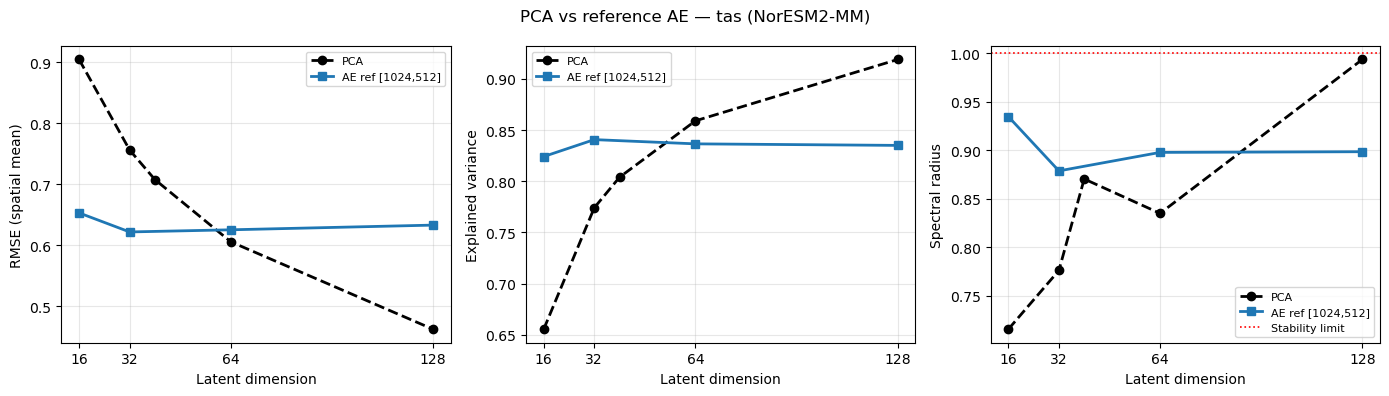

In [29]:
# ── Quick comparison: PCA vs reference AE ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics_to_plot = [
    ("rmse",               "RMSE (spatial mean)",      False),
    ("explained_variance", "Explained variance",       False),
    ("spectral_radius",    "Spectral radius",          True),
]

for ax, (metric, ylabel, draw_boundary) in zip(axes, metrics_to_plot):
    ax.plot(df_pca["latent_dim"], df_pca[metric],
            "o--", color="black", linewidth=2, label="PCA")
    ax.plot(df_ae_ref["latent_dim"], df_ae_ref[metric],
            "s-", color="tab:blue", linewidth=2, label="AE ref [1024,512]")
    if draw_boundary:
        ax.axhline(1.0, color="red", linestyle=":", linewidth=1.2, label="Stability limit")
    ax.set_xlabel("Latent dimension")
    ax.set_ylabel(ylabel)
    ax.set_xticks([16, 32, 64, 128])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"PCA vs reference AE — {NOTEBOOK_VAR} ({MODEL})", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "phase1b_pca_vs_ae_ref.png", dpi=150)
plt.show()


In [30]:
import torch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from fys9429.ae_experiment_runner import ConfigurableMLP, ExperimentRegistry

PLOT_LD = 64   # latent dimension to visualise
n_lat, n_lon = len(lats), len(lons)

# PCA reconstruction (fast)
pca_plot   = SklearnPCA(n_components=PLOT_LD, random_state=SEED)
pcs_pca    = pca_plot.fit_transform(X_ae_mlp)
X_recon_pca = pca_plot.inverse_transform(pcs_pca)

# Load saved AE checkpoint
config_for_ckpt = {"latent_dim": PLOT_LD, **REFERENCE_ARCH}
cid      = ExperimentRegistry.__new__(ExperimentRegistry).config_id(config_for_ckpt)
ckpt     = RESULTS_DIR / "checkpoints" / f"ae_{cid}.pt"

ae_plot = ConfigurableMLP(
    input_dim    = X_ae_mlp.shape[1],
    latent_dim   = PLOT_LD,
    hidden       = tuple(REFERENCE_ARCH["hidden"]),
    dropout      = REFERENCE_ARCH["dropout"],
    use_residual = REFERENCE_ARCH["use_residual"],
)
ae_plot.load_state_dict(torch.load(ckpt, map_location="cpu", weights_only=True))
ae_plot.eval()
X_recon_ae = ae_plot.decode(ae_plot.encode(X_ae_mlp))

rmse_pca = np.sqrt(((X_recon_pca - X_ae_mlp)**2).mean(axis=0))
rmse_ae  = np.sqrt(((X_recon_ae  - X_ae_mlp)**2).mean(axis=0))

T_SAMPLE = 600   # example time step (~late historical period)
orig_map      = X_ae_mlp[T_SAMPLE].reshape(n_lat, n_lon)
recon_pca_map = X_recon_pca[T_SAMPLE].reshape(n_lat, n_lon)
recon_ae_map  = X_recon_ae[T_SAMPLE].reshape(n_lat, n_lon)

print(f'✅  X_recon_pca: {X_recon_pca.shape}  X_recon_ae: {X_recon_ae.shape}')
print(f'    Global mean RMSE — PCA: {rmse_pca.mean():.4f}   AE: {rmse_ae.mean():.4f}')


✅  X_recon_pca: (3012, 55296)  X_recon_ae: (3012, 55296)
    Global mean RMSE — PCA: 0.5984   AE: 0.6356


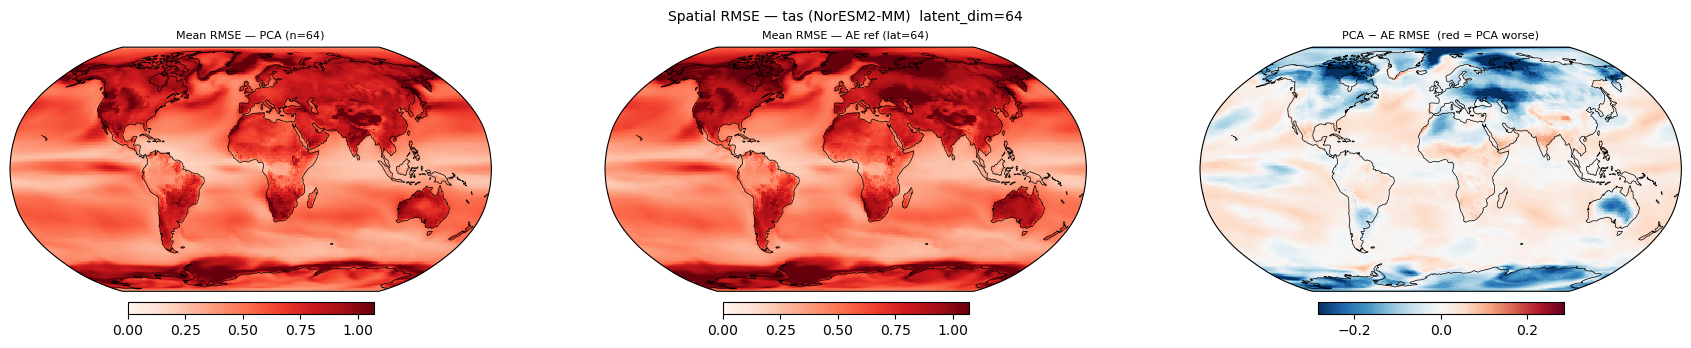

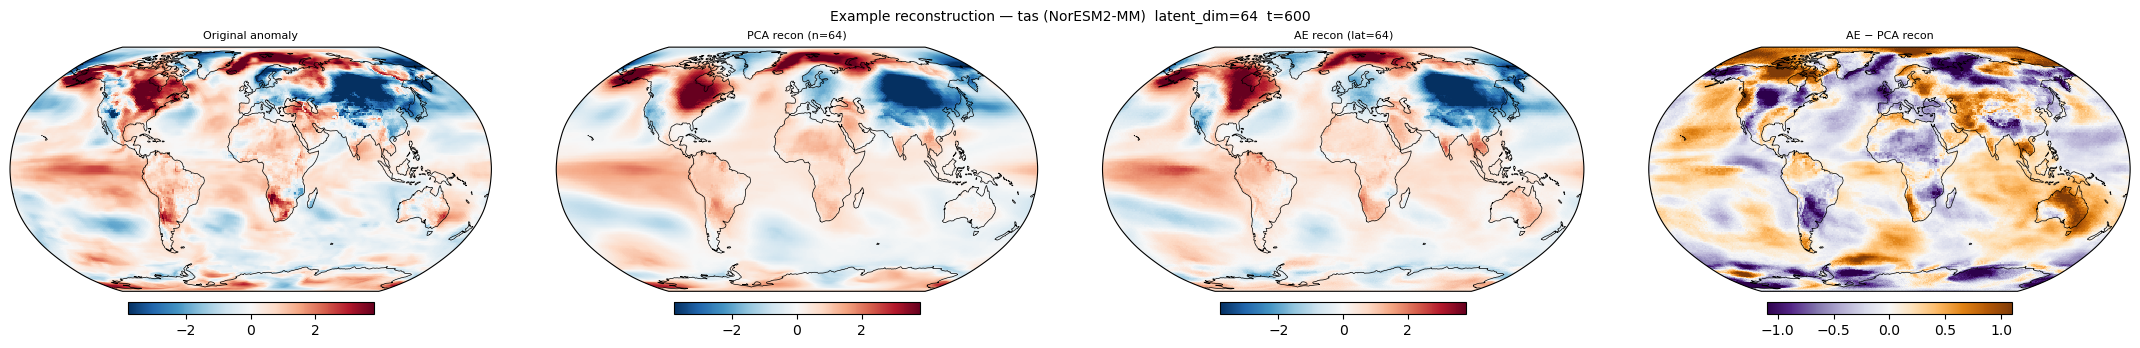

In [31]:
# ── Spatial RMSE maps ──────────────────────────────────────────────────────
def _mapax(ax, data, title, cmap, vmin, vmax):
    im = ax.pcolormesh(lons, lats, data.reshape(n_lat, n_lon), cmap=cmap,
                       vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_title(title, fontsize=8)
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, fraction=0.046)

fig, axes = plt.subplots(1, 3, figsize=(18, 3.5),
                          subplot_kw={'projection': ccrs.Robinson()})
rmax = float(np.nanpercentile(rmse_pca, 97))
dmax = float(np.nanpercentile(np.abs(rmse_pca - rmse_ae), 97))
_mapax(axes[0], rmse_pca, f'Mean RMSE — PCA (n={PLOT_LD})',      'Reds',   0, rmax)
_mapax(axes[1], rmse_ae,  f'Mean RMSE — AE ref (lat={PLOT_LD})', 'Reds',   0, rmax)
_mapax(axes[2], rmse_pca - rmse_ae, 'PCA − AE RMSE  (red = PCA worse)', 'RdBu_r', -dmax, dmax)
fig.suptitle(f'Spatial RMSE — {NOTEBOOK_VAR} ({MODEL})  latent_dim={PLOT_LD}', fontsize=10)
fig.tight_layout()
fig.savefig(FIGURE_DIR / f'phase1b_rmse_maps_ld{PLOT_LD}.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Example reconstruction ──────────────────────────────────────────────────
v = float(np.nanpercentile(np.abs(orig_map), 97))
dv = float(np.nanpercentile(np.abs(recon_ae_map - recon_pca_map), 97))

fig, axes = plt.subplots(1, 4, figsize=(22, 3.5),
                          subplot_kw={'projection': ccrs.Robinson()})
panels = [
    (orig_map,                       'Original anomaly',            'RdBu_r', -v,  v),
    (recon_pca_map,                  f'PCA recon (n={PLOT_LD})',    'RdBu_r', -v,  v),
    (recon_ae_map,                   f'AE recon (lat={PLOT_LD})',   'RdBu_r', -v,  v),
    (recon_ae_map - recon_pca_map,   'AE − PCA recon',             'PuOr_r', -dv, dv),
]
for ax, (data, title, cmap, lo, hi) in zip(axes, panels):
    _mapax(ax, data, title, cmap, lo, hi)
fig.suptitle(
    f'Example reconstruction — {NOTEBOOK_VAR} ({MODEL})  '
    f'latent_dim={PLOT_LD}  t={T_SAMPLE}', fontsize=10)
fig.tight_layout()
fig.savefig(FIGURE_DIR / f'phase1b_recon_example_ld{PLOT_LD}.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Phase 2 — AE Architecture Sweep

Grid: `latent_dim` × `hidden` × `dropout` × `use_residual` = 4 × 3 × 2 × 2 = **48 runs**.  
Completed configs are skipped via the `ExperimentRegistry` (checkpoint in `results/`).

In [35]:
sweep_grid = {
    "latent_dim":   [16, 32, 64, 128],
    "hidden":       [[512], [1024, 512], [1024, 512, 256]],
    "dropout":      [0.1, 0.3],
    "use_residual": [True, False],
    "epochs":       [100],
    "device":       ["auto"],
}

# Quick check: how many unique configs?
from itertools import product
keys   = list(sweep_grid.keys())
combos = list(product(*sweep_grid.values()))
print(f"Total configs: {len(combos)}")

Total configs: 48


In [38]:
df_ae = run_sweep(
    grid=sweep_grid,
    X_ae_mlp=X_ae_mlp,
    X_ae_conv=X_ae_conv,
    lats=lats,
    lons=lons,
    t_glob=t_glob,
    results_dir=SCRATCH_DIR,
    lag_order=LAG_ORDER,
    use_exog="none",
    skip_done=True,
    verbose=True,
)
print(f"\n✅ Sweep complete. {len(df_ae)} runs in registry.")

[1/48] SKIP  {'latent_dim': 16, 'hidden': [512], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto'}
[2/48] SKIP  {'latent_dim': 16, 'hidden': [512], 'dropout': 0.1, 'use_residual': False, 'epochs': 100, 'device': 'auto'}
[3/48] SKIP  {'latent_dim': 16, 'hidden': [512], 'dropout': 0.3, 'use_residual': True, 'epochs': 100, 'device': 'auto'}
[4/48] SKIP  {'latent_dim': 16, 'hidden': [512], 'dropout': 0.3, 'use_residual': False, 'epochs': 100, 'device': 'auto'}
[5/48] SKIP  {'latent_dim': 16, 'hidden': [1024, 512], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto'}
[6/48] SKIP  {'latent_dim': 16, 'hidden': [1024, 512], 'dropout': 0.1, 'use_residual': False, 'epochs': 100, 'device': 'auto'}
[7/48] SKIP  {'latent_dim': 16, 'hidden': [1024, 512], 'dropout': 0.3, 'use_residual': True, 'epochs': 100, 'device': 'auto'}
[8/48] SKIP  {'latent_dim': 16, 'hidden': [1024, 512], 'dropout': 0.3, 'use_residual': False, 'epochs': 100, 'device': 'auto'}
[9/48] SKIP 

       latent=32  hidden=[1024, 512, 256]  dropout=0.1  residual=True  RMSE=0.4129  SR=0.9361  t=94s
[22/48] RUN   {'latent_dim': 32, 'hidden': [1024, 512, 256], 'dropout': 0.1, 'use_residual': False, 'epochs': 100, 'device': 'auto'}
       latent=32  hidden=[1024, 512, 256]  dropout=0.1  residual=False  RMSE=1.1059  SR=0.6537  t=79s
[23/48] RUN   {'latent_dim': 32, 'hidden': [1024, 512, 256], 'dropout': 0.3, 'use_residual': True, 'epochs': 100, 'device': 'auto'}
       latent=32  hidden=[1024, 512, 256]  dropout=0.3  residual=True  RMSE=0.4494  SR=0.9431  t=79s
[24/48] RUN   {'latent_dim': 32, 'hidden': [1024, 512, 256], 'dropout': 0.3, 'use_residual': False, 'epochs': 100, 'device': 'auto'}
       latent=32  hidden=[1024, 512, 256]  dropout=0.3  residual=False  RMSE=1.1449  SR=0.6797  t=87s
[25/48] RUN   {'latent_dim': 64, 'hidden': [512], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto'}
       latent=64  hidden=[512]  dropout=0.1  residual=True  RMSE=0.6089  SR

---
## Phase 3 — Summary & Comparison

Load saved results, merge PCA and AE tables, and produce comparison plots.

In [40]:
# ── Load results ────────────────────────────────────────────────────────────
df_pca_loaded = pd.read_parquet(SCRATCH_DIR / f"pca_results_{NOTEBOOK_VAR}.parquet")
df_ae_loaded  = pd.read_parquet(SCRATCH_DIR / "sweep_results.parquet")

# Tag each table
df_pca_loaded["arch_type"] = "pca"
df_ae_loaded["arch_type"]  = "ae"

# Harmonise column names for shared plotting
df_ae_loaded["n_modes"] = df_ae_loaded["latent_dim"]

# Create a readable architecture label
def _arch_label(row):
    if row["arch_type"] == "pca":
        return "PCA"
    hidden_str = "-".join(str(h) for h in row["hidden"])
    res = "R" if row["use_residual"] else "NR"
    return f"{hidden_str} ({res})"

df_ae_loaded["arch_label"] = df_ae_loaded.apply(_arch_label, axis=1)
df_pca_loaded["arch_label"] = "PCA"

print(f"PCA rows : {len(df_pca_loaded)}")
print(f"AE  rows : {len(df_ae_loaded)}")
print("\nAE columns:", list(df_ae_loaded.columns))

PCA rows : 5
AE  rows : 52

AE columns: ['latent_dim', 'hidden', 'dropout', 'use_residual', 'epochs', 'device', 'rmse', 'explained_variance', 'spatial_corr', 'arctic_rmse', 'sh_rmse', 'skew_mae', 'kurt_mae', 'effective_rank', 'mean_skew', 'mean_kurt', 'mean_acf_lag1', 'mean_acf_lag12', 'corr_matrix_offdiag_mean', 'spectral_radius', 'aic', 'bic', 'ljungbox_mean_pval', 'ks_normality_mean_pval', 'nan_fraction', 'inf_fraction', 'variance_drift_ratio', 'mean_drift_abs', 'train_time_s', 'run_id', 'timestamp', 'arch_type', 'n_modes', 'arch_label']


In [41]:
# ── Best AE per (latent_dim, arch_label): min RMSE over dropout × residual ──
ae_best = (
    df_ae_loaded
    .groupby(["latent_dim", "arch_label"], as_index=False)
    .agg({"rmse": "min", "explained_variance": "max",
          "spectral_radius": "mean", "variance_drift_ratio": "mean",
          "nan_fraction": "mean", "train_time_s": "mean"})
)

# PCA best (only one run per n_modes, so no aggregation needed)
pca_best = df_pca_loaded.copy()
pca_best["latent_dim"] = pca_best["n_modes"]

print(ae_best[["latent_dim", "arch_label", "rmse", "explained_variance", "spectral_radius"]]
      .sort_values(["latent_dim", "arch_label"]).to_string(index=False))

 latent_dim        arch_label     rmse  explained_variance  spectral_radius
         16     1024-512 (NR) 0.732062            0.772332         0.754959
         16      1024-512 (R) 0.441148            0.920035         0.929641
         16 1024-512-256 (NR) 1.115266            0.419604         0.615099
         16  1024-512-256 (R) 0.440859            0.920126         0.933107
         16          512 (NR) 0.675969            0.812969         0.880029
         16           512 (R) 0.724048            0.782248         0.932129
         32     1024-512 (NR) 0.781474            0.737962         0.794045
         32      1024-512 (R) 0.453407            0.914953         0.900614
         32 1024-512-256 (NR) 1.105875            0.430973         0.666710
         32  1024-512-256 (R) 0.412876            0.931217         0.939585
         32          512 (NR) 0.579578            0.865260         0.907035
         32           512 (R) 0.680166            0.811637         0.907072
         64 

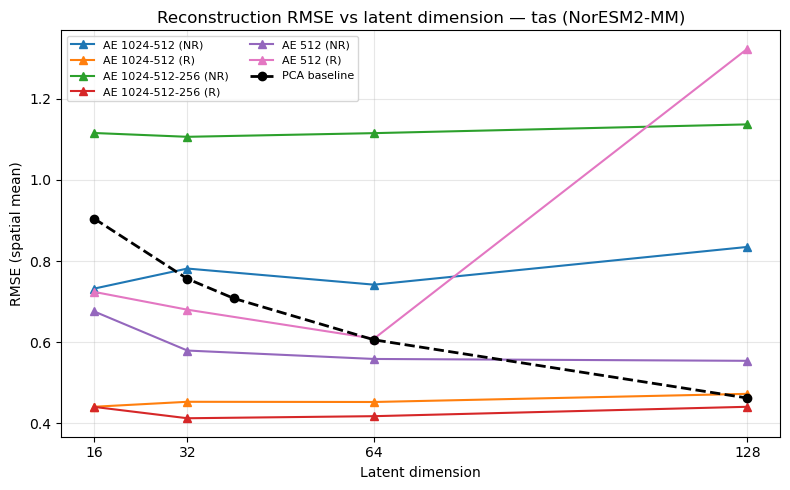

In [42]:
# ── Plot 1: RMSE vs latent_dim (efficiency curve) ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

arch_labels = sorted(ae_best["arch_label"].unique())
colors      = plt.cm.tab10(np.linspace(0, 0.6, len(arch_labels)))

for col, arch in zip(colors, arch_labels):
    sub = ae_best[ae_best["arch_label"] == arch].sort_values("latent_dim")
    ax.plot(sub["latent_dim"], sub["rmse"], marker="^", color=col,
            label=f"AE {arch}", linewidth=1.5)

# PCA baseline
ax.plot(pca_best["latent_dim"], pca_best["rmse"], "o--",
        color="black", label="PCA baseline", linewidth=2)

ax.set_xlabel("Latent dimension")
ax.set_ylabel("RMSE (spatial mean)")
ax.set_title(f"Reconstruction RMSE vs latent dimension — {NOTEBOOK_VAR} ({MODEL})")
ax.set_xticks([16, 32, 64, 128])
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
#fig.savefig(FIGURE_DIR / "efficiency_curve.png", dpi=150)
plt.show()

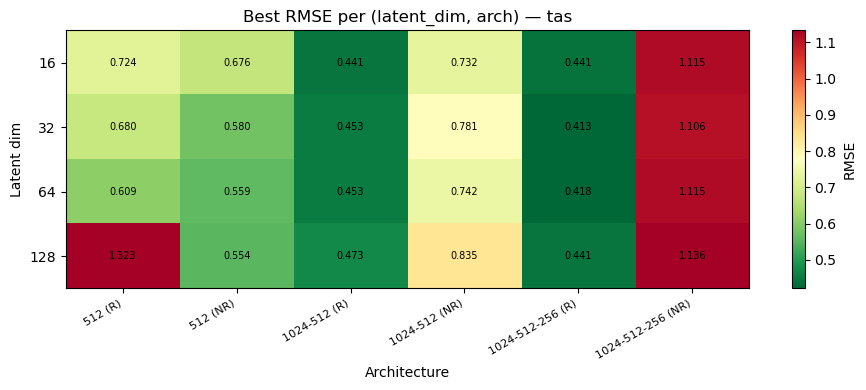

In [47]:
# ── Plot 2: RMSE heatmap — latent_dim × architecture (best over dropout) ───
hidden_labels_ordered = ["512 (R)", "512 (NR)", "1024-512 (R)", "1024-512 (NR)",
                         "1024-512-256 (R)", "1024-512-256 (NR)"]
latent_dims = [16, 32, 64, 128]

# Build pivot: best RMSE per (latent_dim, arch_label)
pivot = ae_best.pivot(index="latent_dim", columns="arch_label", values="rmse")
pivot = pivot.reindex(index=latent_dims)

# Filter to only the columns that exist in the data
available_cols = [c for c in hidden_labels_ordered if c in pivot.columns]
pivot = pivot[available_cols]

fig, ax = plt.subplots(figsize=(len(available_cols) * 1.4 + 1, 4))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn_r",
               vmin=np.nanpercentile(pivot.values, 5),
               vmax=np.nanpercentile(pivot.values, 95))
plt.colorbar(im, ax=ax, label="RMSE")

ax.set_xticks(range(len(available_cols)))
ax.set_xticklabels(available_cols, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(latent_dims)))
ax.set_yticklabels(latent_dims)
ax.set_xlabel("Architecture")
ax.set_ylabel("Latent dim")
ax.set_title(f"Best RMSE per (latent_dim, arch) — {NOTEBOOK_VAR}")

for i in range(len(latent_dims)):
    for j in range(len(available_cols)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=7)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "rmse_heatmap.png", dpi=150)
plt.show()

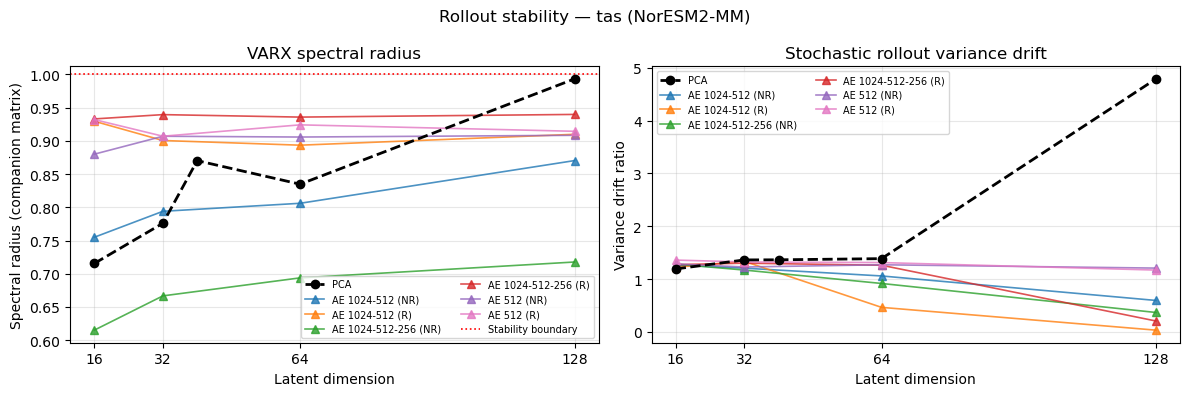

In [44]:
# ── Plot 3: Rollout stability — spectral radius & variance drift ────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, ylabel, title in zip(
    axes,
    ["spectral_radius", "variance_drift_ratio"],
    ["Spectral radius (companion matrix)", "Variance drift ratio"],
    ["VARX spectral radius", "Stochastic rollout variance drift"],
):
    # PCA
    ax.plot(pca_best["latent_dim"], pca_best[metric], "o--",
            color="black", label="PCA", linewidth=2, zorder=3)
    # AE (best)
    for col, arch in zip(colors, arch_labels):
        sub = ae_best[ae_best["arch_label"] == arch].sort_values("latent_dim")
        ax.plot(sub["latent_dim"], sub[metric], marker="^", color=col,
                label=f"AE {arch}", linewidth=1.2, alpha=0.8)

    if metric == "spectral_radius":
        ax.axhline(1.0, color="red", linestyle=":", linewidth=1.2, label="Stability boundary")

    ax.set_xlabel("Latent dimension")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks([16, 32, 64, 128])
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"Rollout stability — {NOTEBOOK_VAR} ({MODEL})", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "rollout_stability.png", dpi=150)
plt.show()

In [45]:
# ── Table: top-10 AE configs by RMSE, annotated with stability ─────────────
cols_show = [
    "latent_dim", "arch_label", "dropout", "use_residual",
    "rmse", "explained_variance", "spectral_radius",
    "variance_drift_ratio", "nan_fraction", "train_time_s",
]
cols_show = [c for c in cols_show if c in df_ae_loaded.columns]

top10 = (
    df_ae_loaded[cols_show]
    .sort_values("rmse")
    .head(10)
    .reset_index(drop=True)
)
print("Top-10 AE configs by RMSE:")
print(top10.to_string())

# Best PCA for reference
pca_ref_cols = [c for c in ["n_modes", "rmse", "explained_variance",
                              "spectral_radius", "variance_drift_ratio"] if c in df_pca_loaded.columns]
print("\nPCA baseline:")
print(df_pca_loaded[pca_ref_cols].to_string(index=False))

Top-10 AE configs by RMSE:
   latent_dim        arch_label  dropout  use_residual      rmse  explained_variance  spectral_radius  variance_drift_ratio  nan_fraction  train_time_s
0          32  1024-512-256 (R)      0.1          True  0.412876            0.931217         0.936086              1.291210           0.0     93.770427
1          64  1024-512-256 (R)      0.1          True  0.417981            0.928653         0.927919              1.271254           0.0     83.772810
2          16  1024-512-256 (R)      0.1          True  0.440859            0.920126         0.925325              1.269359           0.0     90.750850
3         128  1024-512-256 (R)      0.1          True  0.441101            0.919611         0.945670              0.139635           0.0     88.949702
4          16      1024-512 (R)      0.1          True  0.441148            0.920035         0.932095              1.175052           0.0     87.228001
5          64  1024-512-256 (R)      0.3          True  0.447

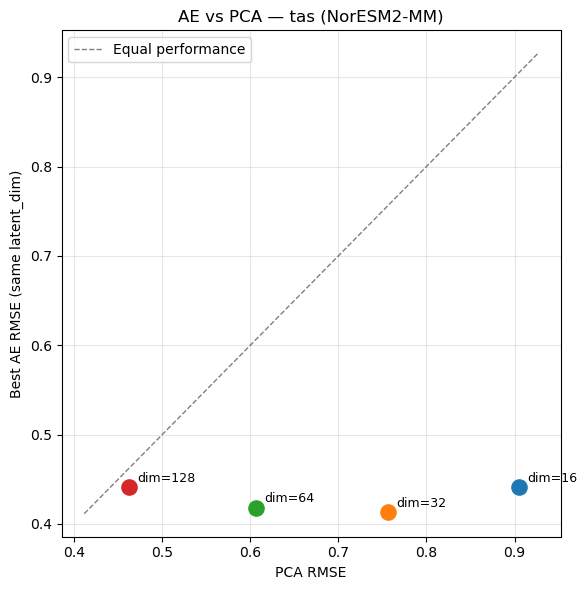

In [46]:
# ── Plot 4: AE vs PCA — matched latent_dim scatter ─────────────────────────
# For each latent_dim, find the best AE config and compare to PCA
best_per_dim = (
    df_ae_loaded
    .sort_values("rmse")
    .groupby("latent_dim", as_index=False)
    .first()
)

fig, ax = plt.subplots(figsize=(6, 6))

for _, row in best_per_dim.iterrows():
    n = int(row["latent_dim"])
    pca_row = pca_best[pca_best["latent_dim"] == n]
    if pca_row.empty:
        continue
    pca_rmse = float(pca_row["rmse"].values[0])
    ae_rmse  = float(row["rmse"])
    ax.scatter(pca_rmse, ae_rmse, s=120, zorder=4)
    ax.annotate(f"dim={n}", (pca_rmse, ae_rmse), textcoords="offset points",
                xytext=(6, 4), fontsize=9)

lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="Equal performance")
ax.set_xlabel("PCA RMSE")
ax.set_ylabel("Best AE RMSE (same latent_dim)")
ax.set_title(f"AE vs PCA — {NOTEBOOK_VAR} ({MODEL})")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "ae_vs_pca_scatter.png", dpi=150)
plt.show()

---
## Phase 4 — Best-Config Deep Dive

Spatial diagnostics and latent-space analysis for the sweep winner.
Also: side-by-side dropout=0.1 vs 0.3 heatmap.


In [48]:
# ── Identify sweep winner & load checkpoint ─────────────────────────────
import torch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from fys9429.ae_experiment_runner import ConfigurableMLP, ExperimentRegistry

best_row = df_ae_loaded.sort_values('rmse').iloc[0]
BEST_LD  = int(best_row['latent_dim'])
BEST_H   = [int(x) for x in best_row['hidden']]
BEST_DO  = float(best_row['dropout'])
BEST_RES = bool(best_row['use_residual'])
BEST_EP  = int(best_row['epochs'])

print(f'Sweep winner: latent_dim={BEST_LD}  hidden={BEST_H}  '
      f'dropout={BEST_DO}  residual={BEST_RES}')
print(f'  RMSE={best_row["rmse"]:.4f}  SR={best_row["spectral_radius"]:.4f}'
      f'  VDR={best_row["variance_drift_ratio"]:.4f}')

n_lat, n_lon = len(lats), len(lons)

# PCA at same latent dim for fair comparison
pca_p4 = SklearnPCA(n_components=BEST_LD, random_state=SEED)
X_recon_pca_p4 = pca_p4.inverse_transform(pca_p4.fit_transform(X_ae_mlp))

# Load best AE checkpoint
best_cfg  = dict(latent_dim=BEST_LD, hidden=BEST_H, dropout=BEST_DO,
                 use_residual=BEST_RES, epochs=BEST_EP, device='auto')
cid_best  = ExperimentRegistry.__new__(ExperimentRegistry).config_id(best_cfg)
ckpt_best = SCRATCH_DIR / 'checkpoints' / f'ae_{cid_best}.pt'
print(f'\nCheckpoint: {ckpt_best.name}  exists={ckpt_best.exists()}')

ae_best_model = ConfigurableMLP(
    input_dim=X_ae_mlp.shape[1], latent_dim=BEST_LD,
    hidden=tuple(BEST_H), dropout=BEST_DO, use_residual=BEST_RES,
)
ae_best_model.load_state_dict(
    torch.load(ckpt_best, map_location='cpu', weights_only=True))
ae_best_model.eval()

X_recon_ae_p4 = ae_best_model.decode(ae_best_model.encode(X_ae_mlp))
pcs_best      = ae_best_model.encode(X_ae_mlp)   # kept for Phase 5

rmse_pca_p4 = np.sqrt(((X_recon_pca_p4 - X_ae_mlp)**2).mean(axis=0))
rmse_ae_p4  = np.sqrt(((X_recon_ae_p4  - X_ae_mlp)**2).mean(axis=0))

print(f'\nSpatial mean RMSE — PCA (n={BEST_LD}): {rmse_pca_p4.mean():.4f}')
print(f'Spatial mean RMSE — best AE:            {rmse_ae_p4.mean():.4f}')
print(f'Improvement: {(rmse_pca_p4.mean()-rmse_ae_p4.mean())/rmse_pca_p4.mean()*100:.1f}%')


Sweep winner: latent_dim=32  hidden=[1024, 512, 256]  dropout=0.1  residual=True
  RMSE=0.4129  SR=0.9361  VDR=1.2912

Checkpoint: ae_b8002e9df40b.pt  exists=True

Spatial mean RMSE — PCA (n=32): 0.7499
Spatial mean RMSE — best AE:            0.4173
Improvement: 44.3%


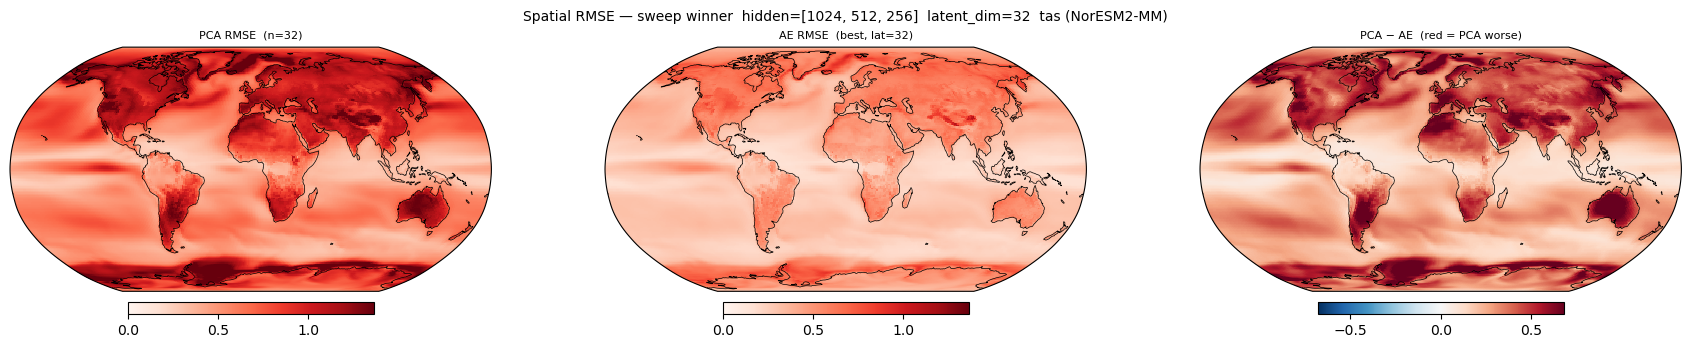

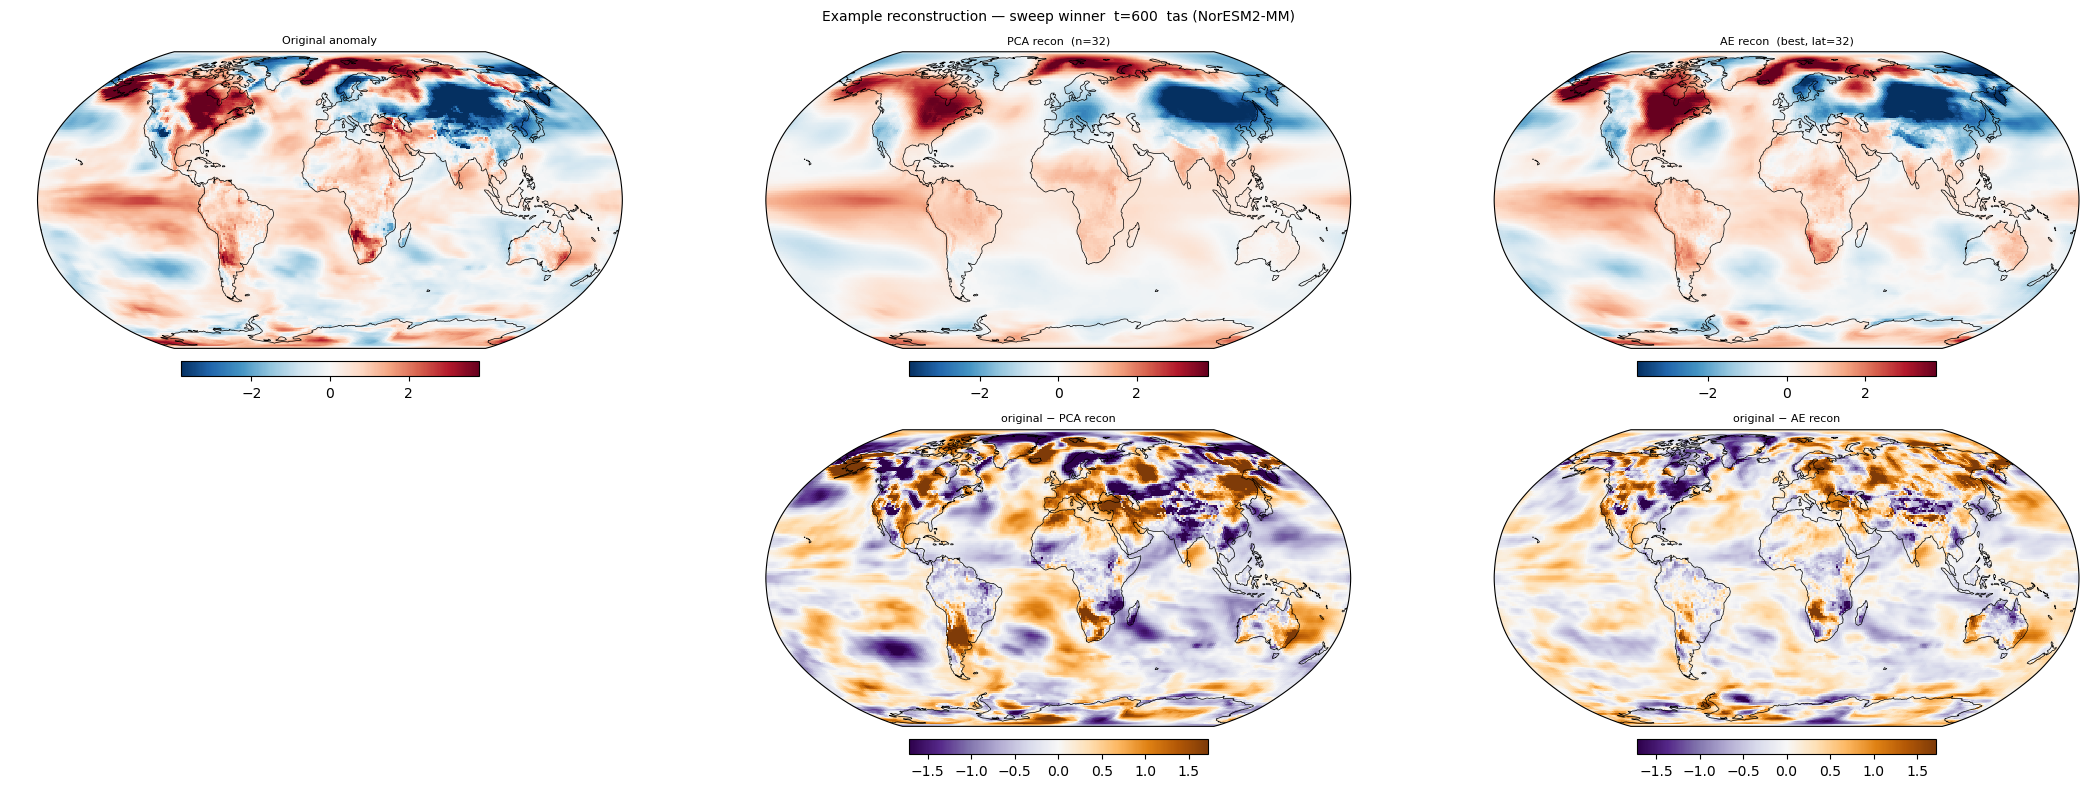

In [ ]:
# ── Spatial RMSE maps: sweep winner vs PCA ──────────────────────────────
def _mapax(ax, data, title, cmap, vmin, vmax):
    im = ax.pcolormesh(lons, lats, data.reshape(n_lat, n_lon), cmap=cmap,
                       vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_title(title, fontsize=8)
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, fraction=0.046)

rmax = float(np.nanpercentile(np.maximum(rmse_pca_p4, rmse_ae_p4), 97))
dmax = float(np.nanpercentile(np.abs(rmse_pca_p4 - rmse_ae_p4), 97))

fig, axes = plt.subplots(1, 3, figsize=(18, 3.5),
                          subplot_kw={'projection': ccrs.Robinson()})
_mapax(axes[0], rmse_pca_p4,              f'PCA RMSE  (n={BEST_LD})',         'Reds',   0,     rmax)
_mapax(axes[1], rmse_ae_p4,               f'AE RMSE  (best, lat={BEST_LD})',  'Reds',   0,     rmax)
_mapax(axes[2], rmse_pca_p4 - rmse_ae_p4, 'PCA − AE  (red = PCA worse)',     'RdBu_r', -dmax, dmax)
fig.suptitle(f'Spatial RMSE — sweep winner  hidden={BEST_H}  '
             f'latent_dim={BEST_LD}  {NOTEBOOK_VAR} ({MODEL})', fontsize=10)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'phase4_rmse_maps_best.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Example time-step reconstruction ────────────────────────────────────────
T_SAMPLE = 600
orig_map      = X_ae_mlp[T_SAMPLE].reshape(n_lat, n_lon)
recon_pca_map = X_recon_pca_p4[T_SAMPLE].reshape(n_lat, n_lon)
recon_ae_map  = X_recon_ae_p4[T_SAMPLE].reshape(n_lat, n_lon)

v  = float(np.nanpercentile(np.abs(orig_map), 97))
dv = float(np.nanpercentile(np.abs(recon_ae_map - recon_pca_map), 97))

fig, axes = plt.subplots(2, 3, figsize=(22, 8),
                          subplot_kw={'projection': ccrs.Robinson()})
axes[1, 0].axis('off')
_mapax(axes[0, 0], orig_map,      'Original anomaly',                 'RdBu_r', -v,  v)
_mapax(axes[0, 1], recon_pca_map, f'PCA recon  (n={BEST_LD})',        'RdBu_r', -v,  v)
_mapax(axes[0, 2], recon_ae_map,  f'AE recon  (best, lat={BEST_LD})', 'RdBu_r', -v,  v)
_mapax(axes[1, 1], orig_map - recon_pca_map, 'original − PCA recon',  'PuOr_r', -dv, dv)
_mapax(axes[1, 2], orig_map - recon_ae_map, 'original − AE recon', 'PuOr_r', -dv, dv)

fig.suptitle(f'Example reconstruction — sweep winner  t={T_SAMPLE}  '
             f'{NOTEBOOK_VAR} ({MODEL})', fontsize=10)
fig.tight_layout()
#fig.savefig(FIGURE_DIR / 'phase4_recon_best.png', dpi=150, bbox_inches='tight')
plt.show()


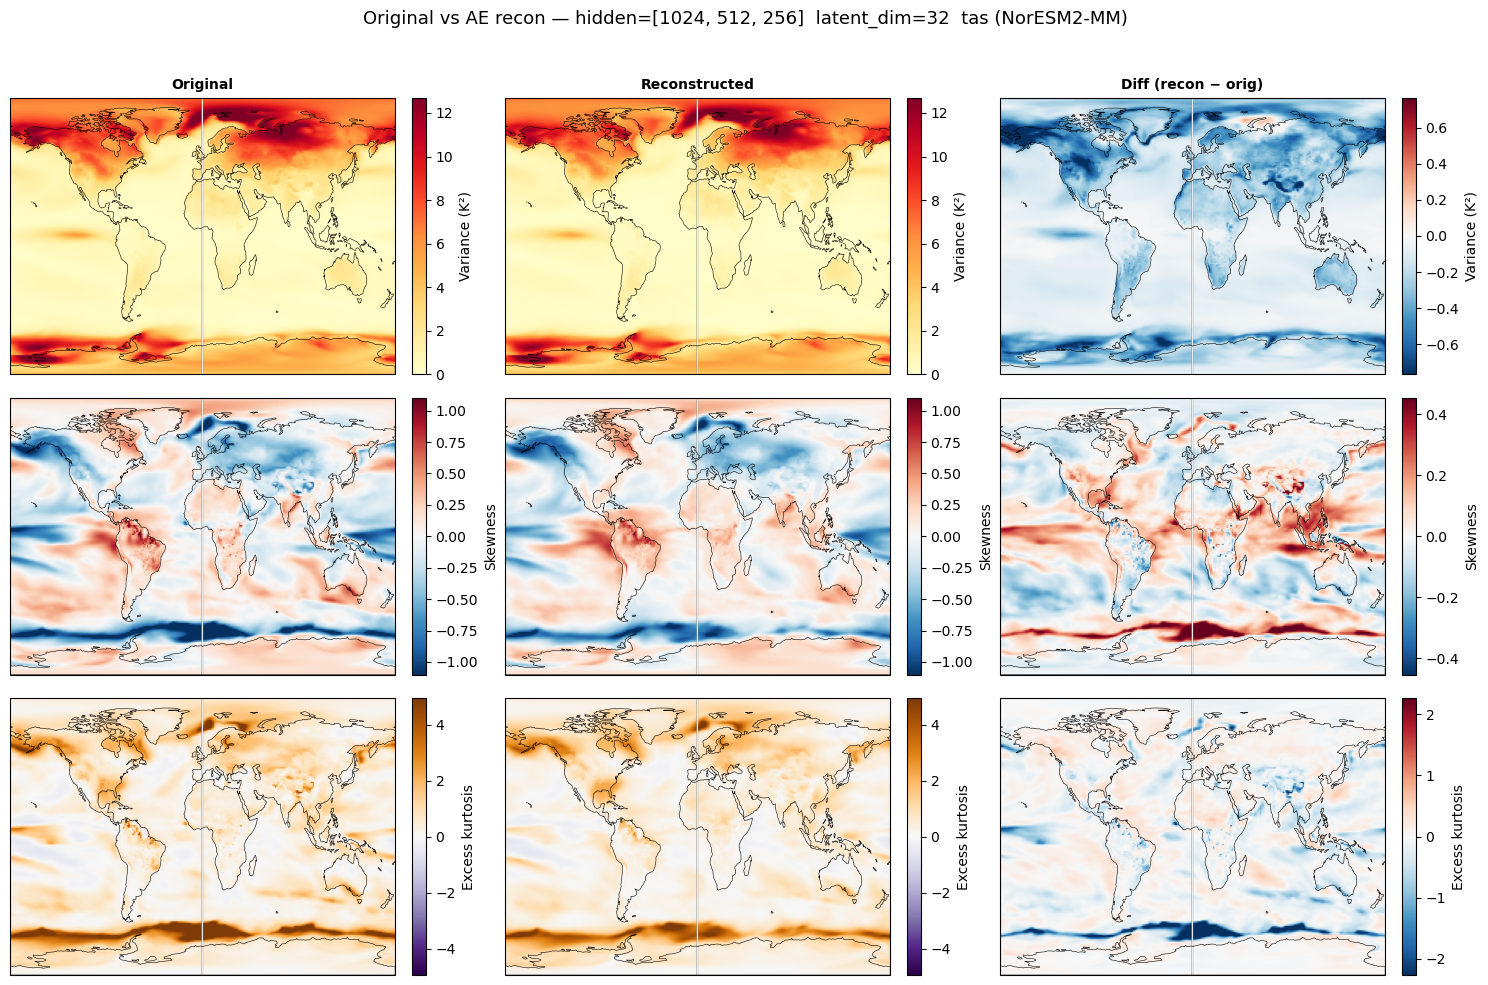

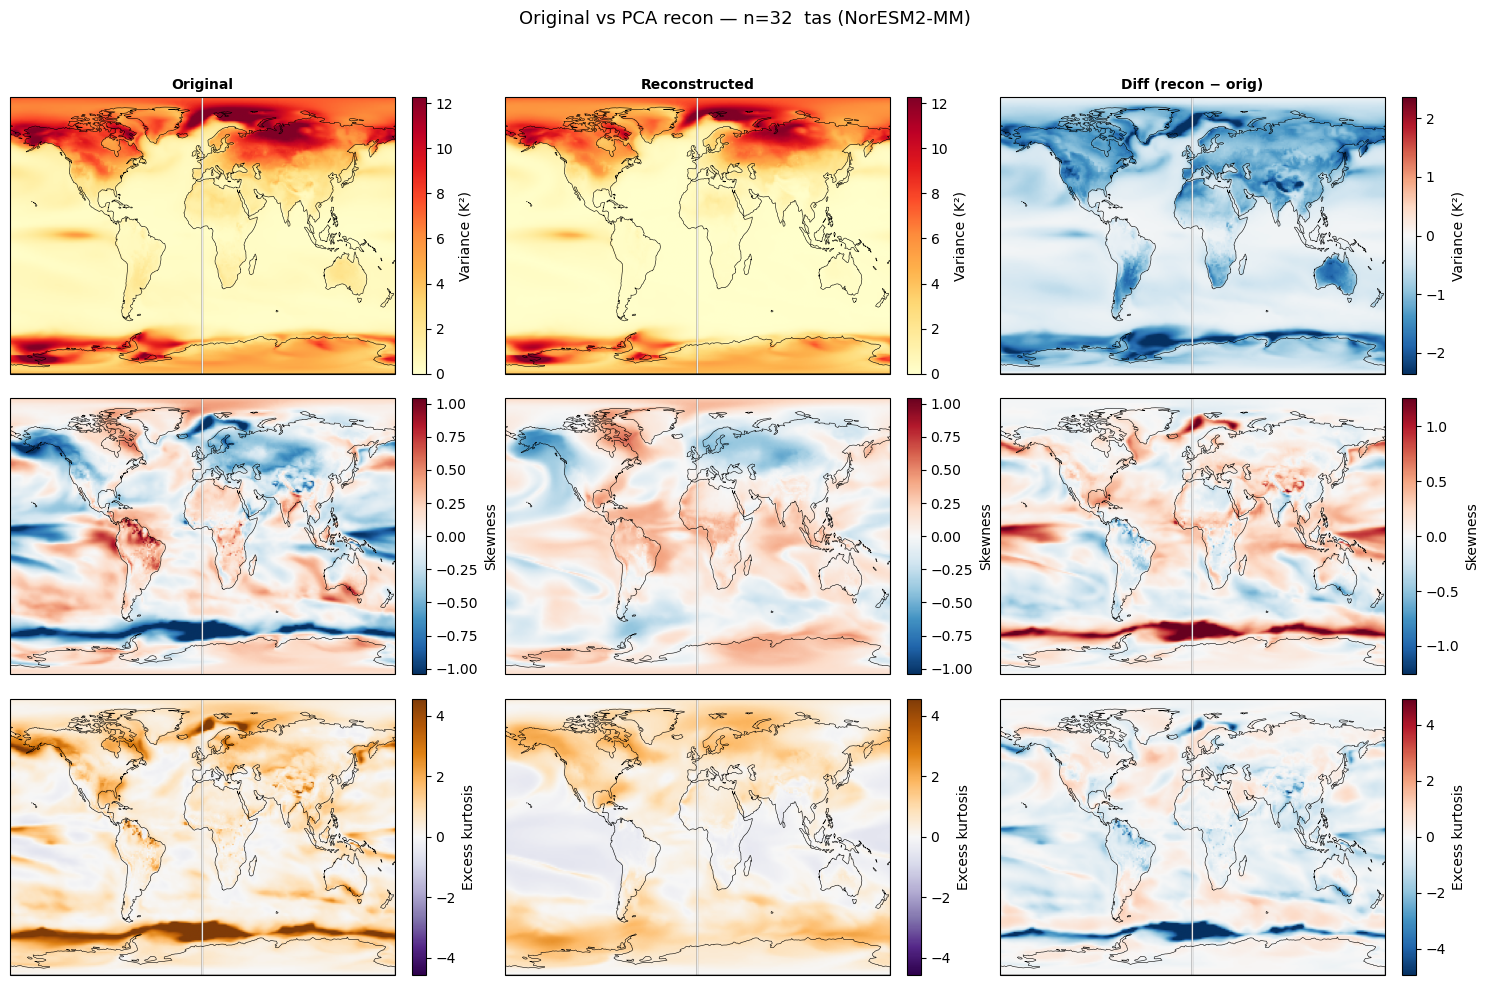

Metric              AE       PCA    AE better?
--------------------------------------------
var_mae         0.1576    0.5718           yes
skew_mae        0.0886    0.2023           yes
kurt_mae        0.2128    0.5449           yes


In [56]:
# ── Higher-order statistics: original vs best-AE vs PCA reconstruction ───────
from fys9429.ae_diagnostics import compare_field_statistics

extent = [float(lons.min()), float(lons.max()),
          float(lats.min()), float(lats.max())]

# Reshape MLP format (T, n_lat*n_lon) → conv format (T, 1, n_lat, n_lon)
def _mlp_to_conv(X):
    return X.reshape(-1, n_lat, n_lon)[:, np.newaxis, :, :]

X_orig_conv   = _mlp_to_conv(X_ae_mlp)
X_ae_conv_p4  = _mlp_to_conv(X_recon_ae_p4)
X_pca_conv_p4 = _mlp_to_conv(X_recon_pca_p4)

# ── AE reconstruction statistics ─────────────────────────────────────────────
stats_ae, fig_ae = compare_field_statistics(
    X_orig_conv, X_ae_conv_p4,
    lats, lons, extent,
    units='K',
    title=f'Original vs AE recon — hidden={BEST_H}  latent_dim={BEST_LD}  {NOTEBOOK_VAR} ({MODEL})',
)
fig_ae.savefig(FIGURE_DIR / 'phase4_field_stats_ae.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PCA reconstruction statistics ────────────────────────────────────────────
stats_pca, fig_pca = compare_field_statistics(
    X_orig_conv, X_pca_conv_p4,
    lats, lons, extent,
    units='K',
    title=f'Original vs PCA recon — n={BEST_LD}  {NOTEBOOK_VAR} ({MODEL})',
)
fig_pca.savefig(FIGURE_DIR / 'phase4_field_stats_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Preservation score summary ────────────────────────────────────────────────
print(f"{'Metric':<12}  {'AE':>8}  {'PCA':>8}  {'AE better?':>12}")
print('-' * 44)
for key in ['var_mae', 'skew_mae', 'kurt_mae']:
    ae_val  = stats_ae['preservation'][key]
    pca_val = stats_pca['preservation'][key]
    print(f"{key:<12}  {ae_val:8.4f}  {pca_val:8.4f}  "
          f"{'yes' if ae_val < pca_val else 'no':>12}")


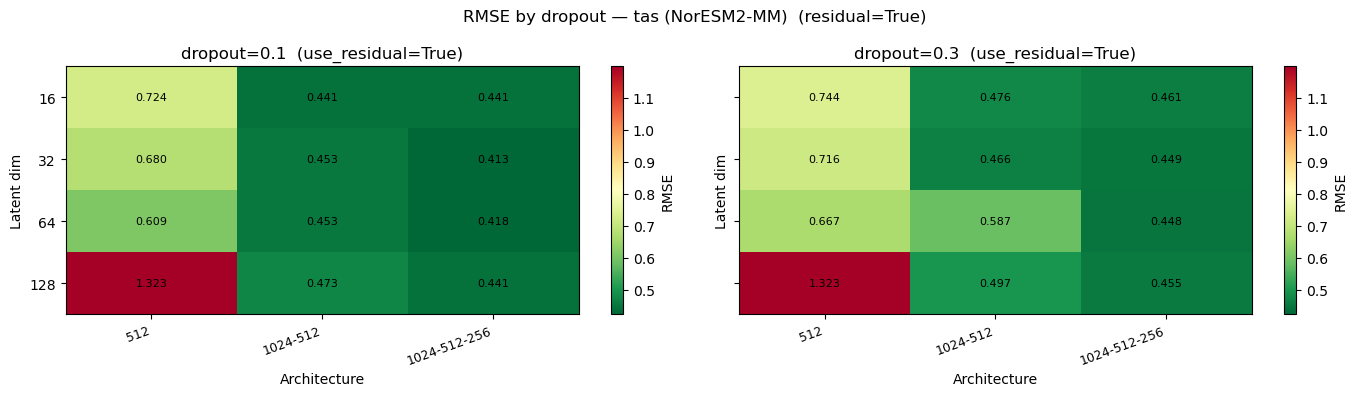

Mean RMSE (residual=True, dropout=0.1): 0.5905
Mean RMSE (residual=True, dropout=0.3): 0.6242


In [51]:
# ── Dropout comparison heatmap: 0.1 vs 0.3 (residual=True only) ─────────
df_ae_loaded['h_str'] = df_ae_loaded['hidden'].apply(
    lambda h: '-'.join(str(int(x)) for x in h))

hidden_order = ['512', '1024-512', '1024-512-256']
latent_dims  = [16, 32, 64, 128]

vmin_do = df_ae_loaded[df_ae_loaded['use_residual']]['rmse'].quantile(0.05)
vmax_do = df_ae_loaded[df_ae_loaded['use_residual']]['rmse'].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, do_val in zip(axes, [0.1, 0.3]):
    sub = df_ae_loaded[(df_ae_loaded['dropout'] == do_val) & df_ae_loaded['use_residual']]
    pivot = sub.pivot_table(index='latent_dim', columns='h_str',
                            values='rmse', aggfunc='min')
    pivot = pivot.reindex(index=latent_dims)
    avail = [c for c in hidden_order if c in pivot.columns]
    pivot = pivot[avail]

    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
                   vmin=vmin_do, vmax=vmax_do)
    plt.colorbar(im, ax=ax, label='RMSE')
    ax.set_xticks(range(len(avail)))
    ax.set_xticklabels(avail, rotation=20, ha='right', fontsize=9)
    ax.set_yticks(range(len(latent_dims)))
    ax.set_yticklabels(latent_dims)
    ax.set_xlabel('Architecture'); ax.set_ylabel('Latent dim')
    ax.set_title(f'dropout={do_val}  (use_residual=True)')
    for i in range(len(latent_dims)):
        for j in range(len(avail)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8)

fig.suptitle(f'RMSE by dropout — {NOTEBOOK_VAR} ({MODEL})  (residual=True)', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'phase4_dropout_heatmap.png', dpi=150)
plt.show()

for do_val in [0.1, 0.3]:
    m = df_ae_loaded[(df_ae_loaded['dropout']==do_val) & df_ae_loaded['use_residual']]['rmse'].mean()
    print(f'Mean RMSE (residual=True, dropout={do_val}): {m:.4f}')


In [52]:
# ── Latent-space diagnostics table (residual=True) ───────────────────────
diag_cols = [
    'latent_dim', 'h_str', 'dropout',
    'effective_rank', 'mean_acf_lag1', 'mean_acf_lag12',
    'mean_skew', 'mean_kurt', 'corr_matrix_offdiag_mean',
    'ks_normality_mean_pval', 'ljungbox_mean_pval',
]
diag_cols = [c for c in diag_cols if c in df_ae_loaded.columns]

diag_df = (
    df_ae_loaded[df_ae_loaded['use_residual']]
    .sort_values(['latent_dim', 'h_str', 'dropout'])
    [diag_cols]
    .reset_index(drop=True)
)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_rows', None)
print('Latent-space diagnostics (residual=True):')
print(diag_df.to_string(index=False))


Latent-space diagnostics (residual=True):
 latent_dim        h_str  dropout  effective_rank  mean_acf_lag1  mean_acf_lag12  mean_skew  mean_kurt  corr_matrix_offdiag_mean  ks_normality_mean_pval  ljungbox_mean_pval
         16     1024-512    0.100          14.352          0.241           0.126      0.222      0.667                     0.094                   0.030               0.004
         16     1024-512    0.300          14.597          0.233           0.122     -0.078      0.682                     0.090                   0.035               0.032
         16 1024-512-256    0.100          14.137          0.232           0.123      0.001      0.469                     0.104                   0.116               0.022
         16 1024-512-256    0.300          14.014          0.241           0.129     -0.045      0.516                     0.100                   0.197               0.178
         16          512    0.100          13.660          0.240           0.127     -0.003  

---
## Phase 5 — VARX Sensitivity & Noise Distribution

Lag-order sensitivity for the sweep winner, then Normal vs Student-*t* residual assessment.


lag=1  SR=0.9208  AIC=160  BIC=162  LB=0.000  VDR=1.216
lag=2  SR=0.9361  AIC=159  BIC=164  LB=0.002  VDR=1.252
lag=3  SR=0.9167  AIC=159  BIC=166  LB=0.177  VDR=1.448
lag=4  SR=0.9162  AIC=160  BIC=168  LB=0.475  VDR=1.728
lag=6  SR=0.9586  AIC=160  BIC=172  LB=0.652  VDR=2.057


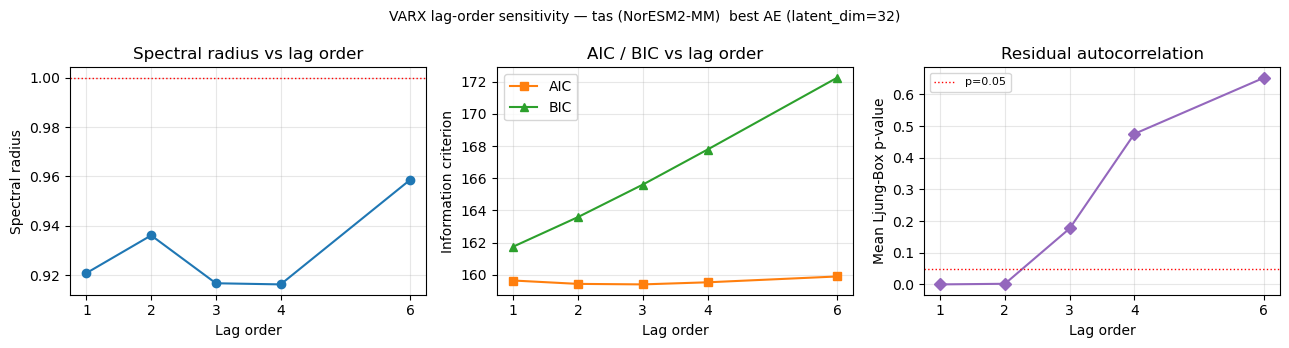


Best lag by AIC: 3  (originally used: 2)


In [53]:
# ── Phase 5a: Lag-order sweep for best AE ───────────────────────────────
pcs_best_np = pcs_best.detach().numpy() if hasattr(pcs_best, 'detach') else np.asarray(pcs_best)

n_time = len(t_glob)
X_exog_none = build_exog_matrix(
    create_harmonic_features(np.arange(n_time), t_glob), 'none')

lag_orders_to_try = [1, 2, 3, 4, 6]
lag_records = []

for lag in lag_orders_to_try:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        vr = VAR(endog=pcs_best_np, exog=X_exog_none).fit(lag)
    nm_lag = types.SimpleNamespace(
        varx_results=vr, lag_order=lag, use_exog='none',
        noise_pc_distribution='normal', t_df=None,
    )
    nm_lag._generate_stochastic_pcs = types.MethodType(
        AEVARXNoiseModel._generate_stochastic_pcs, nm_lag)
    vdiag = compute_varx_diagnostics(nm_lag)
    rdiag = compute_stochastic_rollout_stability(nm_lag, t_glob, n_real=10)
    lag_records.append({'lag_order': lag, **vdiag,
                        'variance_drift_ratio': rdiag['variance_drift_ratio']})
    print(f"lag={lag}  SR={vdiag['spectral_radius']:.4f}  "
          f"AIC={vdiag['aic']:.0f}  BIC={vdiag['bic']:.0f}  "
          f"LB={vdiag['ljungbox_mean_pval']:.3f}  "
          f"VDR={rdiag['variance_drift_ratio']:.3f}")

df_lag = pd.DataFrame(lag_records)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].plot(df_lag['lag_order'], df_lag['spectral_radius'], 'o-', color='tab:blue')
axes[0].axhline(1.0, color='red', linestyle=':', linewidth=1)
axes[0].set(xlabel='Lag order', ylabel='Spectral radius',
            title='Spectral radius vs lag order', xticks=lag_orders_to_try)
axes[1].plot(df_lag['lag_order'], df_lag['aic'], 's-', label='AIC', color='tab:orange')
axes[1].plot(df_lag['lag_order'], df_lag['bic'], '^-', label='BIC', color='tab:green')
axes[1].set(xlabel='Lag order', ylabel='Information criterion',
            title='AIC / BIC vs lag order', xticks=lag_orders_to_try)
axes[1].legend()
axes[2].plot(df_lag['lag_order'], df_lag['ljungbox_mean_pval'], 'D-', color='tab:purple')
axes[2].axhline(0.05, color='red', linestyle=':', linewidth=1, label='p=0.05')
axes[2].set(xlabel='Lag order', ylabel='Mean Ljung-Box p-value',
            title='Residual autocorrelation', xticks=lag_orders_to_try)
axes[2].legend(fontsize=8)
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.suptitle(f'VARX lag-order sensitivity — {NOTEBOOK_VAR} ({MODEL})  '
             f'best AE (latent_dim={BEST_LD})', fontsize=10)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'phase5_lag_sensitivity.png', dpi=150)
plt.show()

best_lag = int(df_lag.loc[df_lag['aic'].idxmin(), 'lag_order'])
print(f'\nBest lag by AIC: {best_lag}  (originally used: {LAG_ORDER})')


Student-t fit for VARX residuals (first 12 dims):
 dim  student_t_df  scale_t  ks_p_normal  ks_p_student_t
   0         9.677   18.600        0.028           0.096
   1        11.973   15.121        0.080           0.369
   2       108.820   17.456        0.301           0.313
   3        13.046   15.542        0.020           0.107
   4        39.090   19.500        0.526           0.570
   5        29.248   15.021        0.006           0.011
   6       217.878   17.765        0.787           0.837
   7        18.759   18.975        0.066           0.195
   8        14.538   16.696        0.000           0.000
   9        15.632   18.316        0.222           0.507
  10        11.416   17.975        0.008           0.079
  11        15.516   19.788        0.156           0.695

Fraction rejected by Normal KS (p<0.05): 40.6%
Median estimated Student-t df: 15.6


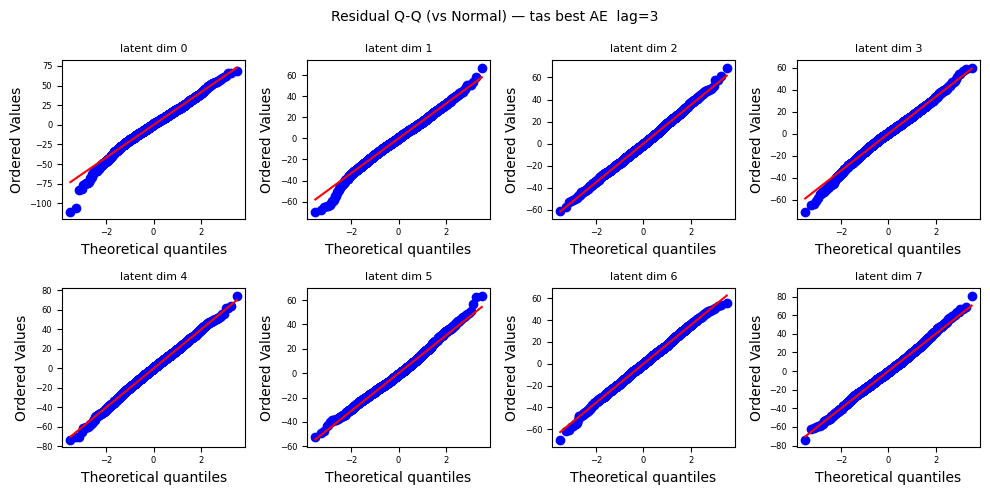

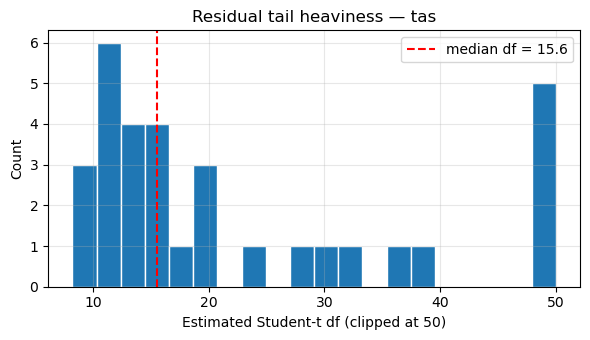

In [54]:
# ── Phase 5b: Normal vs Student-t residuals ─────────────────────────────
from scipy import stats

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    vr_best_lag = VAR(endog=pcs_best_np, exog=X_exog_none).fit(best_lag)

resids = np.asarray(vr_best_lag.resid)   # (T - best_lag, BEST_LD)
n_show = min(8, BEST_LD)

tdist_records = []
for i in range(BEST_LD):
    r = resids[:, i]
    df_t, _, scale_t = stats.t.fit(r, floc=0)
    _, ks_p_norm = stats.kstest(r, 'norm', args=(r.mean(), r.std()))
    _, ks_p_t    = stats.kstest(r, 't',    args=(df_t, 0, scale_t))
    tdist_records.append(dict(dim=i, student_t_df=df_t, scale_t=scale_t,
                               ks_p_normal=ks_p_norm, ks_p_student_t=ks_p_t))

df_tdist = pd.DataFrame(tdist_records)
print('Student-t fit for VARX residuals (first 12 dims):')
print(df_tdist.head(12).to_string(index=False, float_format='{:.3f}'.format))
print(f'\nFraction rejected by Normal KS (p<0.05): '
      f'{(df_tdist["ks_p_normal"] < 0.05).mean():.1%}')
print(f'Median estimated Student-t df: {df_tdist["student_t_df"].median():.1f}')

# Q-Q plots
n_cols = n_show // 2
fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 2.5, 5))
for i, ax in enumerate(axes.flat[:n_show]):
    stats.probplot(resids[:, i], dist='norm', plot=ax)
    ax.set_title(f'latent dim {i}', fontsize=8)
    ax.tick_params(labelsize=6)
fig.suptitle(f'Residual Q-Q (vs Normal) — {NOTEBOOK_VAR} best AE  lag={best_lag}',
             fontsize=10)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'phase5_residual_qq.png', dpi=150)
plt.show()

# Student-t df distribution
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(df_tdist['student_t_df'].clip(upper=50), bins=20,
        color='tab:blue', edgecolor='white')
ax.axvline(df_tdist['student_t_df'].median(), color='red', linestyle='--',
           label=f'median df = {df_tdist["student_t_df"].median():.1f}')
ax.set(xlabel='Estimated Student-t df (clipped at 50)', ylabel='Count',
       title=f'Residual tail heaviness — {NOTEBOOK_VAR}')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'phase5_residual_df_hist.png', dpi=150)
plt.show()


In [55]:
# ── Phase 5c: Champion model summary ────────────────────────────────────
import json as _json

norm_rejected = (df_tdist['ks_p_normal'] < 0.05).mean()
print('=' * 60)
print('CHAMPION MODEL SUMMARY')
print('=' * 60)
print(f'  Variable      : {NOTEBOOK_VAR}  ({MODEL})')
print(f'  Architecture  : hidden={BEST_H}  latent_dim={BEST_LD}')
print(f'  Regularisation: dropout={BEST_DO}  use_residual={BEST_RES}')
print(f'  Training      : epochs={BEST_EP}')
print(f'  VARX lag order: {best_lag}  (AIC-optimal)')
print()
print(f'  Reconstruction RMSE  : {best_row["rmse"]:.4f}')
print(f'  Explained variance   : {best_row["explained_variance"]:.4f}')
print(f'  Spectral radius      : {best_row["spectral_radius"]:.4f}')
print(f'  Variance drift ratio : {best_row["variance_drift_ratio"]:.4f}')
print(f'  NaN fraction         : {best_row["nan_fraction"]:.4f}')
print(f'  Median residual df   : {df_tdist["student_t_df"].median():.1f}  '
      f'(Gaussian rejected in {norm_rejected:.0%} of dims)')
print()
pca_ref = pca_best[pca_best['latent_dim'] == BEST_LD].iloc[0]
print(f'  PCA baseline (n={BEST_LD}) RMSE : {pca_ref["rmse"]:.4f}')
print(f'  AE improvement over PCA        : '
      f'{(pca_ref["rmse"]-best_row["rmse"])/pca_ref["rmse"]*100:.1f}%')
print('=' * 60)

champion = dict(
    variable=NOTEBOOK_VAR, model=MODEL,
    latent_dim=BEST_LD, hidden=BEST_H,
    dropout=BEST_DO, use_residual=BEST_RES, epochs=BEST_EP,
    varx_lag_order=best_lag, use_exog='none',
    noise_pc_distribution='student_t' if norm_rejected > 0.5 else 'normal',
    rmse=float(best_row['rmse']),
    spectral_radius=float(best_row['spectral_radius']),
    checkpoint=str(ckpt_best),
)
champion_path = SCRATCH_DIR / f'champion_{NOTEBOOK_VAR}.json'
champion_path.write_text(_json.dumps(champion, indent=2))
print(f'\n✅ Champion config saved → {champion_path}')


CHAMPION MODEL SUMMARY
  Variable      : tas  (NorESM2-MM)
  Architecture  : hidden=[1024, 512, 256]  latent_dim=32
  Regularisation: dropout=0.1  use_residual=True
  Training      : epochs=100
  VARX lag order: 3  (AIC-optimal)

  Reconstruction RMSE  : 0.4129
  Explained variance   : 0.9312
  Spectral radius      : 0.9361
  Variance drift ratio : 1.2912
  NaN fraction         : 0.0000
  Median residual df   : 15.6  (Gaussian rejected in 41% of dims)

  PCA baseline (n=32) RMSE : 0.7562
  AE improvement over PCA        : 45.4%

✅ Champion config saved → /scratch/johannlf/ae_sweep/champion_tas.json


---
## Phase 6 — Activation, Optimizer & Loss Ablation

One-at-a-time ablation starting from the Phase 2 sweep winner.

- **6a** Activation function — 4 variants, all other hypers fixed  
- **6b** Optimizer × Loss joint grid — 3 × 3 optimizers/losses × lr × weight_decay = 54 configs  


In [57]:
# ── Phase 6a: Activation sweep ───────────────────────────────────────────────
act_grid = dict(
    latent_dim=[32],
    hidden=[[1024, 512, 256]],
    dropout=[0.1],
    use_residual=[True],
    epochs=[100],
    device=['auto'],
    activation=['Hardswish', 'GELU', 'ReLU', 'SiLU'],
)

df_p6a_all = run_sweep(
    act_grid, X_ae_mlp, X_ae_conv,
    lats, lons, t_glob,
    results_dir=SCRATCH_DIR,
    lag_order=LAG_ORDER,
    use_exog='none',
    skip_done=True,
)

# Filter to Phase 6a rows: activation set, no optimizer key
_opt_col_6a = df_p6a_all.get('optimizer', pd.Series(np.nan, index=df_p6a_all.index))
df_p6a = df_p6a_all[df_p6a_all['activation'].notna() & _opt_col_6a.isna()].copy()

print(f'Phase 6a — {len(df_p6a)} configs:')
print(df_p6a[['activation', 'rmse', 'spectral_radius', 'variance_drift_ratio']]
      .sort_values('rmse').to_string(index=False))

BEST_ACT = df_p6a.sort_values('rmse').iloc[0]['activation']
print(f'\n→ Best activation: {BEST_ACT}')


[1/4] RUN   {'latent_dim': 32, 'hidden': [1024, 512, 256], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto', 'activation': 'Hardswish'}
       latent=32  hidden=[1024, 512, 256]  dropout=0.1  residual=True  RMSE=0.4293  SR=0.9384  t=86s
[2/4] RUN   {'latent_dim': 32, 'hidden': [1024, 512, 256], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto', 'activation': 'GELU'}
       latent=32  hidden=[1024, 512, 256]  dropout=0.1  residual=True  RMSE=0.4038  SR=0.9414  t=83s
[3/4] RUN   {'latent_dim': 32, 'hidden': [1024, 512, 256], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto', 'activation': 'ReLU'}
       latent=32  hidden=[1024, 512, 256]  dropout=0.1  residual=True  RMSE=0.5734  SR=0.9415  t=85s
[4/4] RUN   {'latent_dim': 32, 'hidden': [1024, 512, 256], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto', 'activation': 'SiLU'}
       latent=32  hidden=[1024, 512, 256]  dropout=0.1  residual=True  RMSE=0.4013  

In [59]:
# ── Phase 6b: Optimizer × Loss joint grid ────────────────────────────────────
# Fixes best activation from 6a; grid-searches optimizer, loss, lr, weight_decay
optloss_grid = dict(
    latent_dim=[32],
    hidden=[[1024, 512, 256]],
    dropout=[0.1],
    use_residual=[True],
    epochs=[100],
    device=['auto'],
    activation=[BEST_ACT],
    optimizer=['adamw', 'adam'],
    loss=['mse', 'mae', 'huber'],
    lr=[1e-3, 0.01],
    weight_decay=[1e-5],
)

df_p6b_all = run_sweep(
    optloss_grid, X_ae_mlp, X_ae_conv,
    lats, lons, t_glob,
    results_dir=SCRATCH_DIR,
    lag_order=LAG_ORDER,
    use_exog='none',
    skip_done=True,
)

df_p6b = df_p6b_all[df_p6b_all['optimizer'].notna()].copy()

print(f'Phase 6b — {len(df_p6b)} configs')
print('\nMin RMSE by optimizer × loss (marginalised over lr, weight_decay):')
print(df_p6b.groupby(['optimizer', 'loss'])['rmse'].min().unstack().to_string())

best_row_6b = df_p6b.sort_values('rmse').iloc[0]
BEST_OPT  = best_row_6b['optimizer']
BEST_LOSS = best_row_6b['loss']
BEST_LR_6 = float(best_row_6b['lr'])
BEST_WD_6 = float(best_row_6b['weight_decay'])
print(f'\nBest: optimizer={BEST_OPT}  loss={BEST_LOSS}  '
      f'lr={BEST_LR_6:.0e}  wd={BEST_WD_6:.0e}  RMSE={best_row_6b["rmse"]:.4f}')


[1/12] RUN   {'latent_dim': 32, 'hidden': [1024, 512, 256], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto', 'activation': 'SiLU', 'optimizer': 'adamw', 'loss': 'mse', 'lr': 0.001, 'weight_decay': 1e-05}
       latent=32  hidden=[1024, 512, 256]  dropout=0.1  residual=True  RMSE=0.4033  SR=0.9427  t=79s
[2/12] RUN   {'latent_dim': 32, 'hidden': [1024, 512, 256], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto', 'activation': 'SiLU', 'optimizer': 'adamw', 'loss': 'mse', 'lr': 0.01, 'weight_decay': 1e-05}
       latent=32  hidden=[1024, 512, 256]  dropout=0.1  residual=True  RMSE=1.3230  SR=nan  t=86s
[3/12] RUN   {'latent_dim': 32, 'hidden': [1024, 512, 256], 'dropout': 0.1, 'use_residual': True, 'epochs': 100, 'device': 'auto', 'activation': 'SiLU', 'optimizer': 'adamw', 'loss': 'mae', 'lr': 0.001, 'weight_decay': 1e-05}
       latent=32  hidden=[1024, 512, 256]  dropout=0.1  residual=True  RMSE=0.4863  SR=0.9398  t=74s
[4/12] RUN   {'latent_d

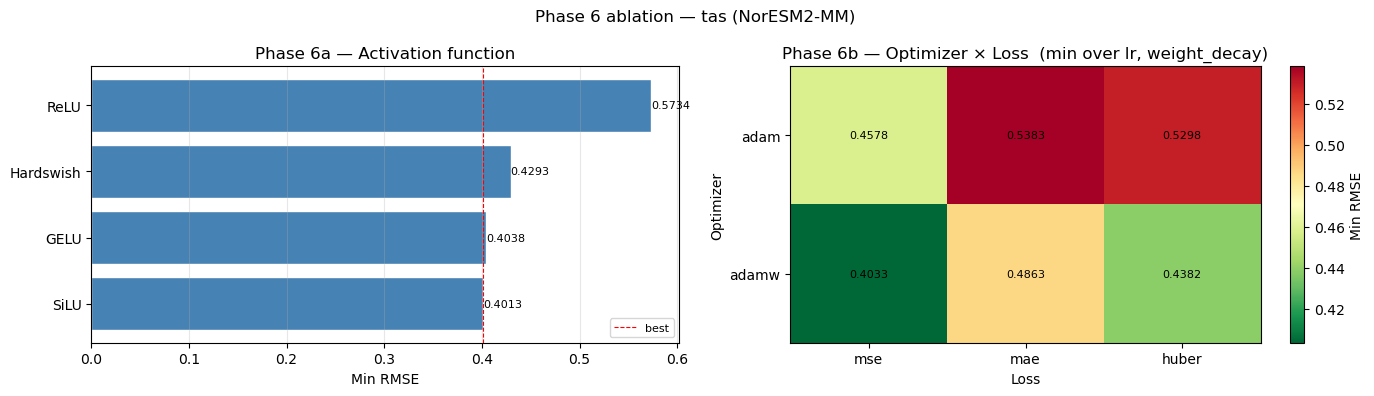

In [60]:
# ── Phase 6 results: bar chart + heatmap ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1: activation bar chart
act_rmse = df_p6a.groupby('activation')['rmse'].min().sort_values()
axes[0].barh(act_rmse.index, act_rmse.values, color='steelblue', edgecolor='white')
axes[0].axvline(act_rmse.min(), color='red', linestyle='--', lw=0.8, label='best')
for i, (name, val) in enumerate(act_rmse.items()):
    axes[0].text(val + 1e-4, i, f'{val:.4f}', va='center', fontsize=8)
axes[0].set(xlabel='Min RMSE', title='Phase 6a — Activation function')
axes[0].legend(fontsize=8)
axes[0].grid(True, axis='x', alpha=0.3)

# Panel 2: optimizer × loss heatmap (min RMSE over lr / weight_decay)
pivot = df_p6b.groupby(['optimizer', 'loss'])['rmse'].min().unstack('loss')
col_order = [c for c in ['mse', 'mae', 'huber'] if c in pivot.columns]
pivot = pivot[col_order]
vmin_h = pivot.values[np.isfinite(pivot.values)].min()
vmax_h = pivot.values[np.isfinite(pivot.values)].max()
im = axes[1].imshow(pivot.values, aspect='auto', cmap='RdYlGn_r',
                    vmin=vmin_h, vmax=vmax_h)
plt.colorbar(im, ax=axes[1], label='Min RMSE')
axes[1].set_xticks(range(len(pivot.columns))); axes[1].set_xticklabels(pivot.columns)
axes[1].set_yticks(range(len(pivot.index)));   axes[1].set_yticklabels(pivot.index)
axes[1].set(xlabel='Loss', ylabel='Optimizer',
            title='Phase 6b — Optimizer × Loss  (min over lr, weight_decay)')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if np.isfinite(v):
            axes[1].text(j, i, f'{v:.4f}', ha='center', va='center', fontsize=8)

fig.suptitle(f'Phase 6 ablation — {NOTEBOOK_VAR} ({MODEL})', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURE_DIR / 'phase6_results.png', dpi=150, bbox_inches='tight')
plt.show()


In [61]:
# ── Phase 6 winner summary ────────────────────────────────────────────────────
import json as _json

p2_baseline_rmse = float(best_row['rmse'])  # Phase 2 sweep winner

print('=' * 60)
print('PHASE 6 WINNER SUMMARY')
print('=' * 60)
print(f'  Variable       : {NOTEBOOK_VAR}  ({MODEL})')
print(f'  Architecture   : hidden={BEST_H}  latent_dim={BEST_LD}')
print(f'  Best activation: {BEST_ACT}')
print(f'    → RMSE       : {df_p6a.sort_values("rmse").iloc[0]["rmse"]:.4f}')
print()
print(f'  Best optimizer : {BEST_OPT}')
print(f'  Best loss      : {BEST_LOSS}')
print(f'  Best lr        : {BEST_LR_6:.1e}')
print(f'  Best weight_decay: {BEST_WD_6:.1e}')
print(f'    → RMSE       : {best_row_6b["rmse"]:.4f}')
print()
p6_improvement = (p2_baseline_rmse - best_row_6b['rmse']) / p2_baseline_rmse * 100
print(f'  Phase 2 baseline RMSE : {p2_baseline_rmse:.4f}')
print(f'  Phase 6 best RMSE     : {best_row_6b["rmse"]:.4f}')
print(f'  Improvement over P2   : {p6_improvement:.2f}%')
print('=' * 60)

champion_p6 = dict(
    variable=NOTEBOOK_VAR, model=MODEL,
    latent_dim=BEST_LD, hidden=BEST_H,
    dropout=0.1, use_residual=True,
    activation=BEST_ACT,
    optimizer=BEST_OPT, loss=BEST_LOSS,
    lr=BEST_LR_6, weight_decay=BEST_WD_6,
    epochs=100,
    rmse_p2_baseline=p2_baseline_rmse,
    rmse_p6_best=float(best_row_6b['rmse']),
    p6_improvement_pct=round(p6_improvement, 3),
)
champion_p6_path = SCRATCH_DIR / f'champion_p6_{NOTEBOOK_VAR}.json'
champion_p6_path.write_text(_json.dumps(champion_p6, indent=2))
print(f'\nChampion config saved -> {champion_p6_path}')


PHASE 6 WINNER SUMMARY
  Variable       : tas  (NorESM2-MM)
  Architecture   : hidden=[1024, 512, 256]  latent_dim=32
  Best activation: SiLU
    → RMSE       : 0.4013

  Best optimizer : adamw
  Best loss      : mse
  Best lr        : 1.0e-03
  Best weight_decay: 1.0e-05
    → RMSE       : 0.4033

  Phase 2 baseline RMSE : 0.4129
  Phase 6 best RMSE     : 0.4033
  Improvement over P2   : 2.31%

Champion config saved -> /scratch/johannlf/ae_sweep/champion_p6_tas.json
